[目录](./00-A目录.ipynb)

# 一维卡尔曼滤波器

In [ ]:
%matplotlib inline

In [ ]:
#format the book
import book_format
book_format.set_style()

我们已经了解了离散贝叶斯滤波器和高斯滤波器，我们现在准备实现一个卡尔曼滤波器。我们将像处理离散贝叶斯滤波器那样——不是从方程开始，我们将根据对问题的推理逐步开发代码。

“一维”的意思是滤波器只跟踪一个状态变量，例如 x 轴上的位置。在后面的章节中，我们将学习一种更通用的多维形式的滤波器，它可以同时跟踪许多状态变量，如位置、速度和加速度。回想一下，我们在 g-h 滤波器中使用速度来获得比单独跟踪位置更好的估计。卡尔曼滤波器也是如此。

那么为什么不直接使用滤波器的多维形式呢？老实说，数学的推导很困难，直接开发滤波器会让人很难理解。忽略数学原理可以让卡尔曼滤波器的实现变得简单。

因此，在本章中，我们将学习如何使用高斯来实现贝叶斯滤波器。这就是卡尔曼滤波器，一个使用高斯的贝叶斯滤波器。在下一章中，我们将实现多维形式，卡尔曼滤波器全部的功能将被实现！

## 问题描述

在**离散贝叶斯滤波器**一章中，我们在一个走廊中跟踪一个移动的物体。假设在最近的黑客马拉松中，有人使用了一个 RFID 跟踪器，可以提供狗的合理准确位置。传感器可以返回狗距离走廊最左端的距离，单位为米。所以，23.4 意味着狗离走廊左端 23.4 米。

传感器不是完美的。23.4 的测量值可能对应于狗的位置是 23.7 或 23.0。但是，并不太可能对应 47.6 的位置。黑客马拉松期间的测试证实了这一结果——传感器是“相对”准确的，虽然有误差，但误差很小。此外，误差似乎均匀分布在真实位置的两侧，在 23 m 的位置可能的测量值为 22.9 或 23.1。我们也许可以用高斯模型建模。

我们预测狗在移动。这种预测并不完美。有时我们的预测值会超调，有时又会欠调。当然一般情况下这种超调或者欠调不会很大。我们也可以用高斯来建模。

## 置信度的高斯分布

我们可以用高斯分布来表示我们对狗的位置的置信度。假设我们相信我们的狗在 10 米的位置，并且置信度的方差是 1 $\mathrm{m} ^2$，或 $\mathcal{N}(10,\, 1)$。概率密度函数 pdf 如下：

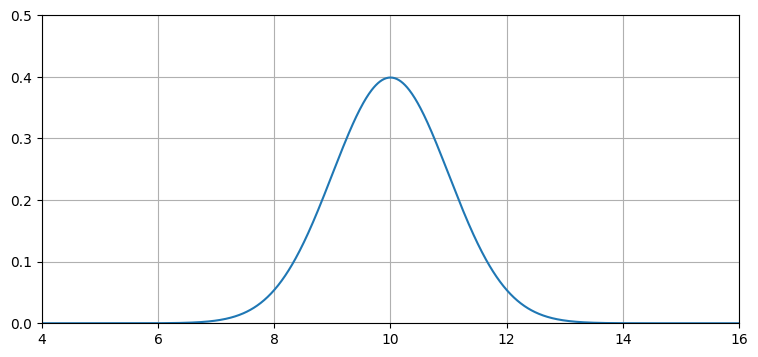

In [ ]:
import filterpy.stats as stats
stats.plot_gaussian_pdf(mean=10., variance=1., 
                        xlim=(4, 16), ylim=(0, .5));

该图描绘了我们对狗的位置的不确定性。它代表了一种相当不准确的置信度。虽然我们认为狗最有可能在 10 米处，但从 9 米到 11 米左右的任何位置都很可能。假设狗静止不动，我们再次查询传感器。这次它可能返回的是 10.2 米。我们可以使用这一额外信息来改进我们的估计吗？

直观的感觉我们应该可以。考虑一下：如果我们查询了传感器 500 次，并且每次它返回 8 到 12 之间的值，所有的值都以 10 为中心，我们应该非常确信狗是在 10 米的位置附近。当然，可能有不同的解释。也许我们的狗会以一种模拟正态分布的随机采样的方式来回随意地徘徊。但这似乎极不可能——我从来没有见过狗那样做。让我们看看来自正态分布 $\mathcal N(10, 1)$ 的 500 次抽样：

Mean of readings is 10.006


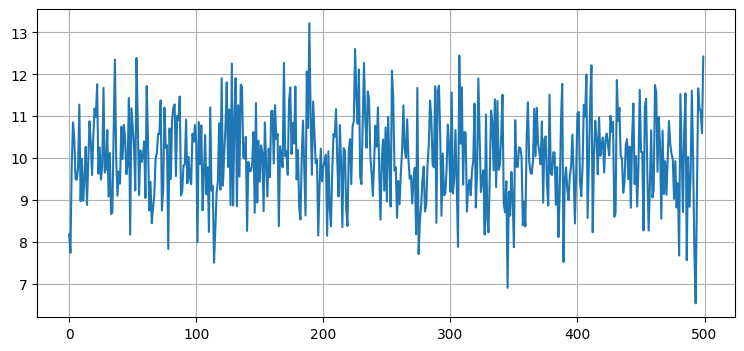

In [ ]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt

xs = range(500)
ys = randn(500)*1. + 10.
plt.plot(xs, ys)
print(f'Mean of readings is {np.mean(ys):.3f}')

目测来看证实了我们的直觉——没有狗会像这样移动。然而，含有噪音的传感器数据肯定会是这样的。计算出的读数的平均值几乎就是 10。假设狗静止不动，我们可以说说狗位于 10 米的位置，方差为 1。

## 利用高斯分布概率来跟踪

离散贝叶斯滤波器使用概率的直方图来跟踪狗。直方图中的每个柱子表示一个位置，它的值是狗处于该位置的概率。

跟踪狗的位置是在每次预测和更新周期中进行的。我们使用了如下方程计算新的概率分布。

$$\begin{aligned} 
\bar {\mathbf x} &= \mathbf x \ast f_{\mathbf x}(\bullet)\, \, &\text{Predict} \\
\mathbf x &= \mathcal L \cdot \bar{\mathbf x}\, \, &\text{Update}
\end{aligned}$$

回想一下 $\bar{\mathbf x}$ 是*先验概率*，$\mathcal L$ 是在给定先验概率 $\bar{\mathbf x}$ 时测量值的*似然*，$f_{\mathbf x}(\bullet)$ 是*过程模型*，$\ast$ 表示*卷积*。$ \mathbf x $ 粗体表示它是数字或矢量的直方图。

这种方法有效，但会导致直方图显示狗可能同时在多个位置。而且，对于复杂的问题，他的计算速度会非常慢。

我们可以用高斯分布 $\mathcal N(x, \sigma^2)$ 替换 $\mathbf x$ 的直方图吗？绝对可以！我们已经学会了如何将置信度表达为高斯分布。只需要一个数字对 $\mathcal N(\mu, \sigma^2)$ 的高斯分布就可以替换整个概率直方图：

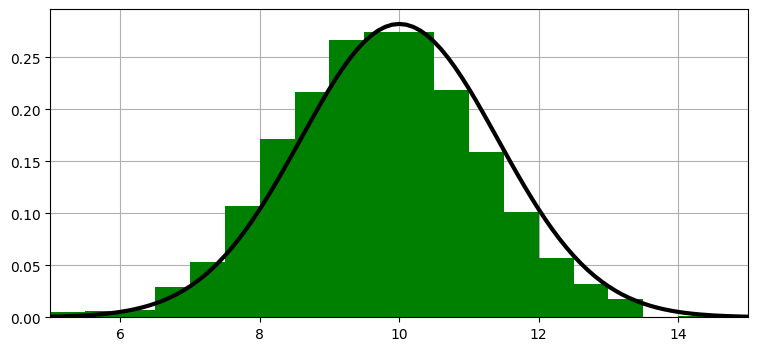

In [ ]:
import kf_book.kf_internal as kf_internal
kf_internal.gaussian_vs_histogram()

我希望你能认识到它的强大之处。我们可以只用一对数字，就可以替换数百到数千个数字：$x = \mathcal N(\mu, \sigma^2)$。

高斯分布的尾部在两侧都会延伸到无穷大，所以它在直方图中能包含任意多个柱形。如果这代表了我们对狗在走廊中的位置的置信度，那么这个高斯分布可以覆盖整个走廊（以及该轴上的整个宇宙）。我们认为这只狗很可能是在 10 米的位置，但他也可能在 8 米处，或 14 米处，或者有极小的概率会在 $\mathrm{10}^{80}$ 米的位置。

在本章中，我们将使用高斯分布来代替直方图：

$$\begin{array}{l|l|c}
\text{离散贝叶斯（discrete Bayes）} & \text{高斯分布（Gaussian）} & \text{步骤}\\
\hline
\bar {\mathbf x} = \mathbf x \ast f(\mathbf x) & 
\bar {x}_\mathcal{N} =  x_\mathcal{N} \, \oplus \, f_{x_\mathcal{N}}(\bullet) &
\text{Predict} \\
\mathbf x = \|\mathcal L \bar{\mathbf x}\| & x_\mathcal{N} = L \, \otimes \, \bar{x}_\mathcal{N} & \text{Update} 
\end{array}$$

其中 $\oplus$ 和 $\otimes$ 意味着在高斯分布上执行的算子。下标 $x_\mathcal{N}$ 表示它是一个高斯分布，但我不会在本书的其余部分中这样表示。

离散贝叶斯滤波器使用卷积进行预测。我们证明根据*全概率定理*，可以计算和，所以也许高斯分布也可以计算和。离散贝叶斯滤波器使用乘法将测量值结合到先验中，所以也许我们可以用乘法处理高斯分布。很容易可以得到：

$$\begin{aligned} 
\bar x &\stackrel{?}{=} x + f_x(\bullet) \\
x &\stackrel{?}{=} \mathcal L \cdot \bar x
\end{aligned}$$

只有当两个高斯的和和是另一个高斯的时，这个方法才有效。否则在第一个轮计算方法后 $x$ 将不再是高斯分布，那么整个方案就无法进行下去了。

## 利用高斯分布来预测

我们使用牛顿运动方程来根据当前速度和先前位置计算当前位置：

$$ \begin{aligned}\bar{x}_k &= x_{k-1} + v_k \Delta t \\
 &= x_{k-1} + f_x\end{aligned}$$

我已经删除了符号 $f_x(\bullet)$ 而使用 $f_x$ 以保持方程整洁。

如果狗的位置在 10 米处，他的速度是 15 米/秒，而每个步长是 2 秒，我们可以得到

$$ \begin{aligned} f_x &= v\Delta t = 15\cdot 2\\
\bar{x}_k &= 10 + (15\cdot 2) = 40 \end{aligned}$$

我们并不确定他目前的位置和速度，所以这并不可行。我们需要用高斯分布来表示不确定性。

位置很容易表示。我们认为 $x$ 符合高斯分布。如果我们认为狗现在在 10 米位置，我们的不确定性的标准差是 0.2 米，我们得到 $x=\mathcal N(10, 0.2^2)$。

我们运动中的不确定性怎么得到？我们假设 $f_x$ 符合高斯分布。如果狗的速度是 15 米/秒，步长时间是 1 秒，不确定性的标准差是 0.7 米/秒，我们得到 $f_x = \mathcal N (15, 0.7^2)$

先验概率的公式是

$$\bar x = x + f_x$$

两个高斯分布的和是多少？这在上一章中我给出了证明：

$$\begin{gathered}
\mu = \mu_1 + \mu_2 \\
\sigma^2 = \sigma^2_1 + \sigma^2_2
\end{gathered}$$

这是个好消息，两个高斯分布的和是另一个高斯分布！

数学上讲的通，但这是否具有直观意义？想想这个抽象方程表示的物理含义。我们有

$$\begin{gathered}
x=\mathcal N(10, 0.2^2)\\
f_x = \mathcal N (15, 0.7^2)
\end{gathered}$$

如果我们将它们相加，得到

$$\begin{aligned}\bar x &= \mu_x + \mu_{f_x} = 10 + 15 &&= 25 \\
\bar\sigma^2 &= \sigma_x^2 + \sigma_{f_x}^2 = 0.2^2 + 0.7^2 &&= 0.53\end{aligned}$$

预测位置是先前位置加上运动的距离。方差是多少呢？对此很难有直观的感受。但是，回想一下，对于离散贝叶斯滤波器的 `predict（）` 函数，我们总是丢失信息。我们无法知道狗在哪里移动，所以置信度应该变小（方差变大）。 $\sigma_{f_x}^2$ 是由于对运动的预测不完善而增加到系统的不确定量，因此我们将其添加到现有的不确定性中。

让我们利用 Python 的 `collection` 模块中的 `namedtuple` 类来实现一个高斯分布对象。我们可以使用一个元组来实现高斯分布，其中 $\mathcal N(10, 0.04)$ 在 Python 中实现为 `g =(10.，0.04)`。我们将使用`g [0]`来获取均值，并使用`g [1]`来获取方差。

`namedtuple`与元组的工作方式相同，只不过为它提供了类型名称和字段名称 你并不需要理解它，我修改了`__repr__`方法以使用本章中的符号显示其值。

In [ ]:
from collections import namedtuple
gaussian = namedtuple('Gaussian', ['mean', 'var'])
gaussian.__repr__ = lambda s: '𝒩(μ={:.3f}, 𝜎²={:.3f})'.format(s[0], s[1])

现在我们可以打印出一个高斯分布

In [ ]:
g1 = gaussian(3.4, 10.1)
g2 = gaussian(mean=4.5, var=0.2**2)
print(g1)
print(g2)

𝒩(μ=3.400, 𝜎²=10.100)
𝒩(μ=4.500, 𝜎²=0.040)


我们可以使用下标或字段名来访问均值和方差：

In [ ]:
g1.mean, g1[0], g1[1], g1.var

(3.4, 3.4, 10.1, 10.1)

这是我们对预测函数的实现，其中`pos`和`movement`分别是一个高斯分布元组 ($\mu$, $\sigma^2$)：

In [ ]:
def predict(pos, movement):
    return gaussian(pos.mean + movement.mean, pos.var + movement.var)

我们来试试吧。初始位置为高斯分布$\mathcal N(10, 0.2^2)$并且运动量也是高斯分布$\mathcal N (15, 0.7^2)$时的先验概率是多少？

In [ ]:
pos = gaussian(10., .2**2)
move = gaussian(15., .7**2)
predict(pos, move)

𝒩(μ=25.000, 𝜎²=0.530)

这只狗在 25 米处的方差为 0.53 $\text{m}^2$，这和我们手工计算的结果是一样的。

## 利用高斯分布更新

离散贝叶斯滤波器在概率直方图中对我们对狗的位置的置信度进行编码。分布是离散的和多模的，即狗可能同时处于两个位置，并且这些位置是离散的。

我们建议用高斯分布替换直方图。离散贝叶斯滤波器使用下面的代码来计算后验概率：

```python
def update(likelihood, prior):
    posterior = likelihood * prior
    return normalize(posterior)
```

这是一个等式的实现：

$$x = \| \mathcal L\bar x \|$$

我们刚刚已经证明我们可以用高斯分布表示先验状态。那似然呢？似然是给定当前状态的测量值的概率。我们已经学会了如何将测量结果表示为高斯分布。例如，也许我们的传感器认为狗在 23 米处，标准差为 0.4 米。我们把测量结果表示为可能性就是$z = \mathcal N (23, 0.16)$。

似然和先验状态都用高斯模型建模。我们可以把高斯分布相乘吗？两个高斯分布的乘积是另一个高斯分布吗？

第一个问题的答案是肯定的，对于第二个问题则几乎是！在上一章中，我证明了两个高斯分布的乘积与另一个高斯分布成正比。

$$\begin{aligned}
\mu &= \frac{\sigma_1^2 \mu_2 + \sigma_2^2 \mu_1} {\sigma_1^2 + \sigma_2^2}, \\
\sigma^2 &= \frac{\sigma_1^2\sigma_2^2}{\sigma_1^2+\sigma_2^2}
\end{aligned}$$

我们可以立即推断出几件事。如果我们将结果进行标准化，则该乘积是另一种高斯分布。如果一个高斯分布是似然，第二个是先验状态，那么均值就是先验状态和测量值的均值的缩放和。方差是先验和测量的方差的组合。最后，方差完全不受均值的影响！

我们用贝叶斯术语这样表述：

$$\begin{aligned}
\mathcal N(\mu, \sigma^2) &= \| prior \cdot likelihood \|\\
&= \| \mathcal{N}(\bar\mu, \bar\sigma^2)\cdot \mathcal{N}(\mu_z, \sigma_z^2) \|\\
&= \mathcal N(\frac{\bar\sigma^2 \mu_z + \sigma_z^2 \bar\mu}{\bar\sigma^2 + \sigma_z^2},\frac{\bar\sigma^2\sigma_z^2}{\bar\sigma^2 + \sigma_z^2})
\end{aligned}$$

如果我们在函数`gaussian_multiply()`中实现它，我们可以实现我们滤波器的更新步骤

In [ ]:
def gaussian_multiply(g1, g2):
    mean = (g1.var * g2.mean + g2.var * g1.mean) / (g1.var + g2.var)
    variance = (g1.var * g2.var) / (g1.var + g2.var)
    return gaussian(mean, variance)

def update(prior, likelihood):
    posterior = gaussian_multiply(likelihood, prior)
    return posterior

# test the update function
predicted_pos = gaussian(10., .2**2)
measured_pos = gaussian(11., .1**2)
estimated_pos = update(predicted_pos, measured_pos)
estimated_pos

𝒩(μ=10.800, 𝜎²=0.008)

如果我们使用具体的名称，这可能会更清楚：

```python
def update_dog(dog_pos, measurement):
    estimated_pos = gaussian_multiply(measurement, dog_pos)
    return estimated_pos  
```

这样写不抽象，有助于理解，但它是很糟糕的编码方式。我们需要编写一个适用于任何问题的卡尔曼滤波器，而不仅仅是为了跟踪走廊中的狗，因此我们不会在其中使用带有“狗”的变量名称。此外，这种形式掩盖了我们将似然乘以先验概率的事实。

我们已经实现了滤波器大部分的功能，但我担心这一步仍然有点令人困惑。我断言我们可以将两个高斯分布相乘并且它能正确执行更新步骤，但为什么这是真的？让我们花些时间理解高斯分布的乘法。

### 理解高斯分布乘法

让我们画出$\mathcal{N}(10,\, 1) \times \mathcal{N}(10,\, 1)$的概率密度函数 pdf。你能不看结果想象出它的形状吗？新的均值是多少？曲线会变的更宽，还是更窄，还是与$\mathcal{N}(10,\, 1)$相同？

𝒩(μ=10.000, 𝜎²=0.500)


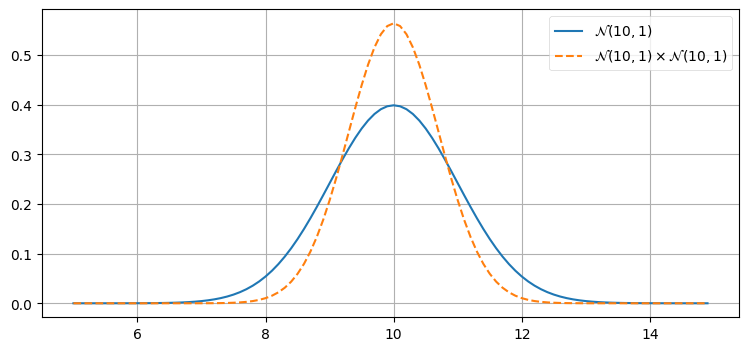

In [ ]:
z = gaussian(10., 1.)  # Gaussian N(10, 1)

product = gaussian_multiply(z, z)

xs = np.arange(5, 15, 0.1)
ys = [stats.gaussian(x, z.mean, z.var) for x in xs]
plt.plot(xs, ys, label='$\mathcal{N}(10,1)$')

ys = [stats.gaussian(x, product.mean, product.var) for x in xs]
plt.plot(xs, ys, label='$\mathcal{N}(10,1) \\times \mathcal{N}(10,1)$', ls='--')
plt.legend()
print(product)

相乘的结果比原始高斯分布变得更高更窄，但均值没有变化。这符合你的直观感觉吗？

假设这是两个测量值的高斯分布。如果我每次测量两次并每次的结果是 10 米，我应该得出结论，长度接近 10 米。因此，平均值应该是 10。认为长度实际上是 11 或 9.5 是没有意义的。另外，我对两次测量比一次测量更有信心，因此结果的方差应该更小。

“测量两次，一次切割（三思而后行）”是众所周知的说法。高斯乘法就是这个物理事实的数学模型。

我们不太可能连续两次获得相同的测量值。现在让我们画出 $\mathcal{N}(10.2,\, 1) \times \mathcal{N}(9.7,\, 1)$的概率密度函数 pdf。您认为结果是怎样的？想一想，然后看看图表。

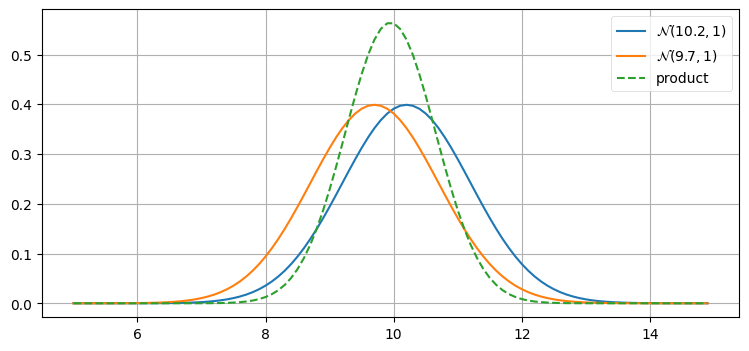

In [ ]:
def plot_products(g1, g2): 
    plt.figure()
    product = gaussian_multiply(g1, g2)

    xs = np.arange(5, 15, 0.1)
    ys = [stats.gaussian(x, g1.mean, g1.var) for x in xs]
    plt.plot(xs, ys, label='$\mathcal{N}$'+'$({},{})$'.format(g1.mean, g1.var))

    ys = [stats.gaussian(x, g2.mean, g2.var) for x in xs]
    plt.plot(xs, ys, label='$\mathcal{N}$'+'$({},{})$'.format(g2.mean, g2.var))

    ys = [stats.gaussian(x, product.mean, product.var) for x in xs]
    plt.plot(xs, ys, label='product', ls='--')
    plt.legend();
    
z1 = gaussian(10.2, 1)
z2 = gaussian(9.7, 1)
 
plot_products(z1, z2)

如果你要求两个人测量桌子与墙壁之间的距离，一个人得到 10.2 米，另一个得到 9.7 米。如果你认为两者的测量技术相同，你最好的猜测结果必须是平均值，则为 9.95 米。

回想一下 g-h 过滤器。我们认为，如果我在两个秤上称重，第一个读 160 磅而第二个读 170 磅，两者同样准确，最好的估计是 165 磅。此外，相比对 160 磅或 170 磅，我们认为结果是 165 磅更有可能。因为如果两者都没有太大偏差，我现在有两个读数，都接近这个估计，都不会太错。

这在更复杂的情况下可能会变得反直觉，所以让我们进一步考虑它。也许更合理的假设是一个人犯了一个错误，真正的距离是 10.2 或 9.7，但肯定不是 9.95。当然这是可能的。但是我们知道我们测量值有噪声，所以我们没有理由认为其中一个测量没有噪音，或者一个人犯了一个严重错误，以至于要放弃他的测量。鉴于所有可用信息，最佳估计必须为 9.95。

在卡尔曼滤波器的更新步骤中，我们没有像在 g-h 过滤器中实现的逻辑那样，在合并测量之前组合两个测量值，而是一个测量和先验概率。这在数学上是等效的，不论我们合并两个测量的信息，或者测量和预测。

我们再来看看。一个相当不准确的先验概率 $\mathcal N(8.5, 1.5)$，和一个精确地测量值$\mathcal N(10.2, 0.5)$。“准确”的意思是传感器方差小于先验概率的方差，而不是我知道狗的位置相比比 8.5 更接近 10.2。接下来我会在绘制一个相反的组合：准确的先验概率$\mathcal N(8.5, 0.5)$和不准确测量的$\mathcal N(10.2, 1.5)$。

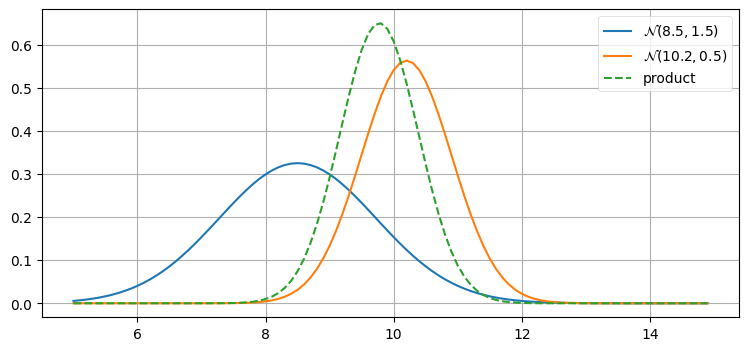

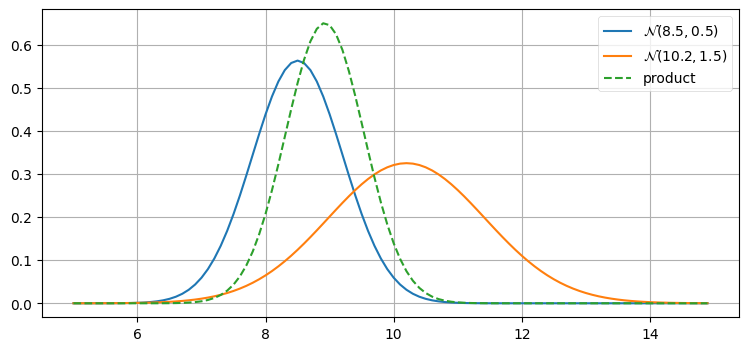

In [ ]:
prior, z = gaussian(8.5, 1.5), gaussian(10.2, 0.5)
plot_products(prior, z)

prior, z = gaussian(8.5, 0.5), gaussian(10.2, 1.5)
plot_products(prior, z)

乘法结果的高斯分布比任一输入都高。这是有道理的——我们已经整合了信息，因此我们的方差应该减少了。并注意结果更接近具有较小方差的输入。我们对这个值更有信心，所以对它赋予了更大的权重。

这*似乎*是有效的，但它是否真的正确？关于这一点还有很多需要讨论，但我希望得到一个有效的过滤器，这样你就可以用具体方式先来实践它。之后我们将重新审视高斯乘法并确定其正确性。

### 互动示例

这个交互式代码提供了滑块来改变两个相乘的高斯分布的均值和方差。移动滑块时，图片会重新绘制。将光标放在代码单元格内，然后按 CTRL + Enter 执行它。

In [ ]:
from ipywidgets import interact

def interactive_gaussian(m1, m2, v1, v2):
    g1 = gaussian(m1, v1)
    g2 = gaussian(m2, v2)
    plot_products(g1, g2)
    
interact(interactive_gaussian,
         m1=(5, 10., .5), m2=(10, 15, .5), 
         v1=(.1, 2, .1), v2=(.1, 2, .1));

interactive(children=(FloatSlider(value=7.5, description='m1', max=10.0, min=5.0, step=0.5), FloatSlider(value…

## 第一个卡尔曼滤波器

让我们回到具体术语并实现卡尔曼滤波器。我们已经实现了`update()`和`predict()`函数。我们只需编写一些模板代码来模拟狗的运动并创建测量值。我在`kf_internal`中实现了一个`DogSimulation`类。

该模板代码通过定义平均值，方差，并生成狗运动的仿真数据来设置问题。

In [ ]:
import kf_book.kf_internal as kf_internal
from kf_book.kf_internal import DogSimulation

np.random.seed(13)

process_var = 1. # variance in the dog's movement
sensor_var = 2. # variance in the sensor

x = gaussian(0., 20.**2)  # dog's position, N(0, 20**2)
velocity = 1
dt = 1. # time step in seconds
process_model = gaussian(velocity*dt, process_var) # displacement to add to x
  
# simulate dog and get measurements
dog = DogSimulation(
    x0=x.mean, 
    velocity=process_model.mean, 
    measurement_var=sensor_var, 
    process_var=process_model.var)

# create list of measurements
zs = [dog.move_and_sense() for _ in range(10)]

下面是一个卡尔曼滤波器。

In [ ]:
print('PREDICT\t\t\tUPDATE')
print('     x      var\t\t  z\t    x      var')

# perform Kalman filter on measurement z
for z in zs:    
    prior = predict(x, process_model)
    likelihood = gaussian(z, sensor_var)
    x = update(prior, likelihood)

    kf_internal.print_gh(prior, x, z)

print()
print('final estimate:        {:10.3f}'.format(x.mean))
print('actual final position: {:10.3f}'.format(dog.x))

PREDICT			UPDATE
     x      var		  z	    x      var
  1.000  401.000	1.354	  1.352   1.990
  2.352    2.990	1.882	  2.070   1.198
  3.070    2.198	4.341	  3.736   1.047
  4.736    2.047	7.156	  5.960   1.012
  6.960    2.012	6.939	  6.949   1.003
  7.949    2.003	6.844	  7.396   1.001
  8.396    2.001	9.847	  9.122   1.000
 10.122    2.000	12.553	 11.338   1.000
 12.338    2.000	16.273	 14.305   1.000
 15.305    2.000	14.800	 15.053   1.000

final estimate:            15.053
actual final position:     14.838


下面是滤波器的动画。预测值用红色三角形绘制。在预测之后，过滤器接收下一个测量值，绘制为黑色圆圈。然后，滤波器在两者之间形成估计部分。

In [ ]:
from kf_book import book_plots as book_plots
from ipywidgets.widgets import IntSlider

# save output in these lists for plotting
xs, predictions = [], []

process_model = gaussian(velocity, process_var) 

# perform Kalman filter
x = gaussian(0., 20.**2)
for z in zs:    
    prior = predict(x, process_model)
    likelihood = gaussian(z, sensor_var)
    x = update(prior, likelihood)

    # save results
    predictions.append(prior.mean)
    xs.append(x.mean)

def plot_filter(step):
    plt.cla()
    step -= 1
    i = step // 3 + 1
 
    book_plots.plot_predictions(predictions[:i])    
    if step % 3 == 0:
        book_plots.plot_measurements(zs[:i-1])
        book_plots.plot_filter(xs[:i-1])
    elif step % 3 == 1:
        book_plots.plot_measurements(zs[:i])
        book_plots.plot_filter(xs[:i-1])
    else:
        book_plots.plot_measurements(zs[:i])
        book_plots.plot_filter(xs[:i])

    plt.xlim(-1, 10)
    plt.ylim(0, 20)
    plt.legend(loc=2);
interact(plot_filter, step=IntSlider(value=1, min=1, max=len(predictions)*3));

interactive(children=(IntSlider(value=1, description='step', max=30, min=1), Output()), _dom_classes=('widget-…

我绘制了先验（标记为*prediction*），测量值和滤波器输出。对于循环的每次迭代，我们形成先验，然后进行测量，形成测量值的似然，然后将似然结合到先验中。

如果你查看绘图，你可以看到滤波器估计始终在测量和预测之间。回想一下，对于 g-h 滤波器，我们认为估计值必须始终在测量值和先验值之间。选择两个值之外的值是没有意义的。如果我预测我在 10 岁，但我测量是 9 岁，那么认为我在 8 岁或 11 岁时是愚蠢的。

## 代码详解

现在让我们来看看代码。

```python
process_var = 1.
sensor_var = 2.
```

这些是过程模型和传感器的方差。传感器方差的含义应该很清楚——它表示每次测量值的方差。过程方差是过程模型中存在多少误差。我们预测，在每个时间周期内，狗向前移动一米。但是狗并不会按我们所期望的那样做，像狗粮或松鼠的气味会改变他的运动轨迹。如果这是一个响应数字指令的机器人，那么性能会好得多，也许方差将是 $\sigma^2=.05$。这些不是“魔法”数字; 方差的平方根是以米为单位的距离的误差。很容易通过输入数字使卡尔曼滤波器工作，但如果这些数字不能反映现实，则滤波器的性能会很差。

```python
x = gaussian(0., 20.**2)
```

这是狗的初始位置，表示为高斯分布。初始位置为 0 米，方差为 400 米$^2$，标准差为 20 米。你可以将它看做“我认为在 0 正负 60 米内的准确率为 99.7％”。这是因为对于高斯分布来说，约 99.7％ 的值落在平均值的 $\pm3\sigma$ 内。

```python
process_model = gaussian(velocity, process_var)
```

这是过程模型——描述我们的狗是如何运动的。我如何知道速度是多少？魔法？将其视为预测值，或者我们可能有速度传感器。如果这是一个机器人，那么这将是机器人的控制输入。在随后的章节中，我们将学习如何处理没有速度传感器或输入的情况，因此请先接受这里的简化处理。

接下来，我们初始化仿真并创建 10 个测量值：

```python
dog = DogSimulation(
    x0=x.mean, 
    velocity=process_model.mean, 
    measurement_var=sensor_var, 
    process_var=process_model.var)

zs = [dog.move_and_sense() for _ in range(10)]
```

然后，进入到 `predict() ... update()` 循环

```python
for z in zs:
    prior = predict(x, process_model)
    likelihood = gaussian(z, sensor_var)
    x = update(prior, likelihood)
```

通过打印的结果来看，第一次循环后 `prior` 是 `(1.0,401.0)`。在预测之后，我们认为我们处于 1.0 米处，并且方差从 400 上升到 401。方差变得更糟了，这总会在预测步骤期间发生，因为它涉及信息的丢失。

然后我们使用 `prior` 作为当前位置来调用更新函数。

我得到了这个结果： `pos = (1.352, 1.990), z = 1.354`。

我们看看发生了什么？狗实际上是在 1.0 米处，但由于传感器噪音，测量位置是 1.354。这与预测值 1 相差很远。先验的方差是 401 m $^2$。大的方差意味着置信度非常低，因此滤波器估计位置更接近测量值：1.352。

现在看看方差：1.99 m $^2 $。它从 401 m $^2 $大幅下降。为什么呢？RFID 传感器的方差相当小，为 2.0 m $^2$，所以我们比先验更信任它。但是，之前的置信度确实包含了一些有用的信息，所以我们的方差现在略小于 2.0。

现在仅需让软件循环，依次调用 `predict()` 和 `update()`。到最后，最终估计位置为 15.053，而实际位置为 14.838。方差已收敛到 1.0 m $^2$。

现在看看绘制的结果。用黑色圆圈表示带有噪声的测量值，用实线蓝色线表示滤波器结果。两者都含有噪音，但请注意测量值的噪音更大。我用红色三角形绘制了预测值（先验状态）。估计值总是在先验和测量之间。这是你的第一个卡尔曼滤波器，它似乎可以工作！

仅仅适用几行代码就可以实现滤波。大多数代码是为了执行初始化，数据存储，模拟狗的移动和打印结果。执行滤波的代码非常简洁：

```python
prior = predict(x, process_model)
likelihood = gaussian(z, sensor_var)
x = update(prior, likelihood)
```

如果我们没有使用`predict`和`update`函数，代码可能是这样：

```python
for z in zs:
    # predict
    dx = velocity*dt
    pos = pos + dx
    var = var + process_var

    # update
    pos  = (var*z + sensor_var*pos) / (var + sensor_var)
    var = (var * sensor_var) / (var + sensor_var)
```    

只需 5 行非常简单的数学计算就可以实现整个滤波器！

在这个例子中，我只绘制了 10 个数据点，因此 print 语句的输出不会让我们感到压力。现在让我们输入更多的数据看看滤波器的性能。用虚线之间的浅阴影黄色区域来表示方差。我增加了过程模型和传感器的方差的大小，因此它们更容易在图表上看到——对于真正的卡尔曼滤波器，你当然不会随机更改这些值。

	4.4502 2.6507 2.2871 2.1955 2.1712
	2.1647 2.1629 2.1625 2.1623 2.1623
	2.1623 2.1623 2.1623 2.1623 2.1623
	2.1623 2.1623 2.1623 2.1623 2.1623
	2.1623 2.1623 2.1623 2.1623 2.1623


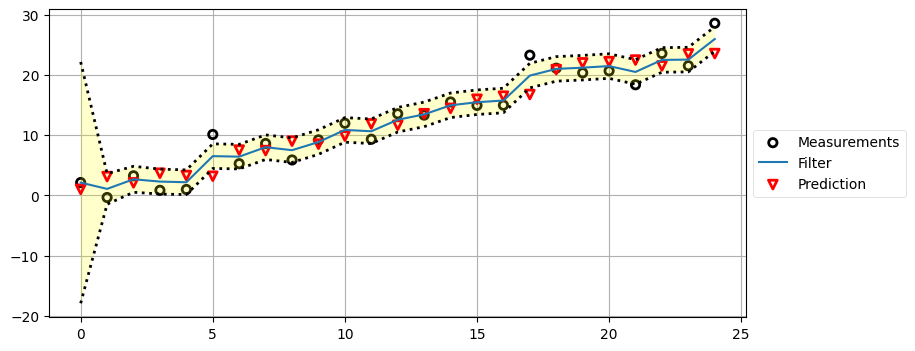

In [ ]:
process_var = 2.
sensor_var = 4.5
x = gaussian(0., 400.)
process_model = gaussian(1., process_var)
N = 25

dog = DogSimulation(x.mean, process_model.mean, sensor_var, process_var)
zs = [dog.move_and_sense() for _ in range(N)]

xs, priors = np.zeros((N, 2)), np.zeros((N, 2))
for i, z in enumerate(zs):
    prior = predict(x, process_model)    
    x = update(prior, gaussian(z, sensor_var))
    priors[i] = prior
    
    xs[i] = x

book_plots.plot_measurements(zs)
book_plots.plot_filter(xs[:, 0], var=priors[:, 1])
book_plots.plot_predictions(priors[:, 0])
book_plots.show_legend()
kf_internal.print_variance(xs)

在这里我们可以看到方差在 9 个步骤后收敛到 2.1623。这意味着我们对位置的估计非常有信心。标准差等于 $\sigma = 1.47$ 米。与此相反，传感器的标准差为 $\sigma = 2.12$ 米。我们对于前几次测量值并不确定，这是由于我们对初始位置的不确定性造成的，但滤波器能够快速收敛到一个方差低于传感器方差的估计值！

该代码完全实现了卡尔曼滤波器。如果你尝试阅读其他文献，你可能会感到惊讶，因为那些书中有着无穷无尽的数学证明。只要我们打算*使用*这些方程而不是*推导*它们，那么这些公式还是容易理解的。此外，我希望你能够对正在发生的事情有一个直观感受。我们用高斯分布表示置信度，随着时间的推移它会变得越来越准，因为能获取更多的测量值，这意味着我们有更多的数据可供使用。

### 练习：修改方差

修改`process_var`和`sensor_var`的值，并注意它们对滤波器和方差的影响。哪个方差收敛影响更大？例如，下面两组，哪个可以得到更小的方差：

```python
process_var = 40
sensor_var = 2
```
    
或者是:

```python
process_var = 2
sensor_var = 40
```

### KF 动画

如果您在浏览器中阅读此内容，您将可以在这句话下方直观查看滤波器追踪狗的动画。

<img src='animations/05_dog_track.gif'>

顶部曲线图以绿色显示滤波器的输出，使用红色虚线显示测量值。底部的图显示了每一步的高斯分布。

当追踪刚开始时，你可以看到测量结果与初始预测相差很大。此时高斯概率很小（曲线低而宽），因此滤波器不信任其预测。结果，滤波器大幅调整其估计。随着滤波器的更新，你可以看到高斯分布变得更高，表明估计更加确定，滤波器的输出变得非常接近直线。在“x = 15”或更大时，你可以看到测量中存在大量噪声，但与第一次噪声测量的变化相比，滤波器对其没有特别大的反应。

## 卡尔曼增益

我们看到滤波器是有效的。现在让我们回到数学计算来了解下发生了什么。后验$x$根据先验和似然 ($\mathcal L \bar x$) 计算得出，其中两者都是高斯分布。

因此，后验的平均值由下式得出：

$$
\mu=\frac{\bar\sigma^2\, \mu_z + \sigma_z^2 \, \bar\mu} {\bar\sigma^2 + \sigma_z^2}
$$

我使用下标$ z $来表示测量值。我们可以将其重写为：

$$\mu = \left( \frac{\bar\sigma^2}{\bar\sigma^2 + \sigma_z^2}\right) \mu_z + \left(\frac{\sigma_z^2}{\bar\sigma^2 + \sigma_z^2}\right)\bar\mu$$

在这种形式中，很容易看出我们正在按比例缩放测量值和先验值：

$$\mu = W_1 \mu_z + W_2 \bar\mu$$

权重的和为 1，因为分母是归一化项。我们引入一个新术语，$ K = W_1 $，于是：

$$\begin{aligned}
\mu &= K \mu_z + (1-K) \bar\mu\\
&= \bar\mu + K(\mu_z - \bar\mu)
\end{aligned}$$

其中

$$K = \frac {\bar\sigma^2}{\bar\sigma^2 + \sigma_z^2}$$

$ K $就是*卡尔曼增益*。这是卡尔曼滤波器的关键。它是一个缩放项，它得到$ \mu_z $和$ \bar\mu $之间的值。

让我们举几个例子吧。如果测量值的精度是先验值高 9 倍，即$\bar\sigma^2 = 9\sigma_z^2$，那么

$$\begin{aligned}
\mu&=\frac{9 \sigma_z^2 \mu_z + \sigma_z^2\, \bar\mu} {9 \sigma_z^2 + \sigma_\mathtt{z}^2} \\
&= \left(\frac{9}{10}\right) \mu_z + \left(\frac{1}{10}\right) \bar\mu
\end{aligned}
$$

因此$K = \frac 9 {10}$，后验值就等于，测量的十分之九加上先验的十分之一。

如果测量和先验准确性相同，则$\bar\sigma^2 = \sigma_z^2$，那么

$$\begin{gathered}
\mu=\frac{\sigma_z^2\,  (\bar\mu + \mu_z)}{2\sigma_\mathtt{z}^2} \\
= \left(\frac{1}{2}\right)\bar\mu + \left(\frac{1}{2}\right)\mu_z
\end{gathered}$$

得到的是二者的平均值。这种情况下，计算两个同样准确的值的平均值是显而易见的。

我们还可以用卡尔曼增益来计算方差：

$$\begin{aligned}
\sigma^2 &= \frac{\bar\sigma^2 \sigma_z^2 } {\bar\sigma^2 + \sigma_z^2} \\
&= K\sigma_z^2 \\
&= (1-K)\bar\sigma^2 
\end{aligned}$$

我们可以通过下图来理解这一点：

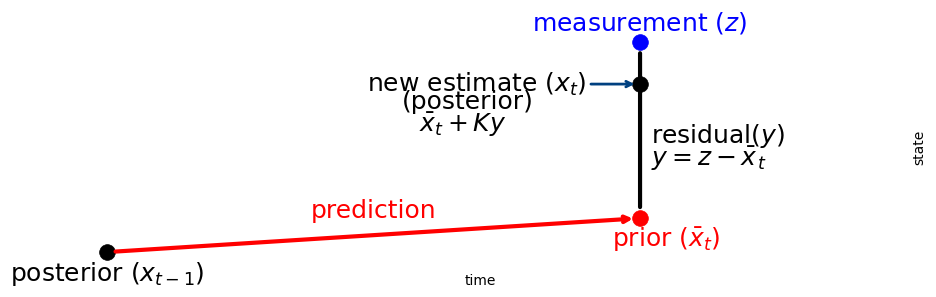

In [ ]:
import kf_book.book_plots as book_plots
book_plots.show_residual_chart()

卡尔曼增益 $K$ 是一个选择残差值的比例因子。可以用它等效地实现`update()`和`predict()`：

In [ ]:
def update(prior, measurement):
    x, P = prior        # mean and variance of prior
    z, R = measurement  # mean and variance of measurement
    
    y = z - x        # residual
    K = P / (P + R)  # Kalman gain

    x = x + K*y      # posterior
    P = (1 - K) * P  # posterior variance
    return gaussian(x, P)

def predict(posterior, movement):
    x, P = posterior # mean and variance of posterior
    dx, Q = movement # mean and variance of movement
    x = x + dx
    P = P + Q
    return gaussian(x, P)

为什么我用这种形式写它，为什么我选择了这些可怕的变量名？一些相关的原因是在大多数书籍和论文通常会以这种形式呈现卡尔曼滤波器。我从贝叶斯原理推导出的滤波器并不是不为人所知，它并没有经常被使用。替代的推导则会导出这种形式的方程。此外，多元卡尔曼滤波器的方程看起来几乎与这些方程完全相同。所以，你需要学习和理解它们。

`z`，`P`，`Q`和`R`的名称是从哪里来的呢？你会在本书的其余部分看到它们的使用。在文献中，几乎普遍将$R$用于测量噪声，$Q$用于过程噪声，$P$用于状态方差。使用$z$表示测量值很常见，尽管不是普遍的。几乎你读过的每一本书和每一篇论文都会使用这些变量名称。你需要习惯他们。

这也是学习滤波的有效方式。这就是我们推导 g-h 滤波器的方式。它强调获取残差$y = \mu_z - \bar\mu$，把卡尔曼增益作为先验值和测量值中的不确定性的比率$ K = P /（P + R）$，并通过先验加上$ Ky $来计算后验。

贝叶斯方法在这种形式下是模糊的，因为我们用似然乘以先验。这两个观点其实是等价的，因为数学计算是相同的。我之所以选择贝叶斯方法，是因为我认为它对概率推理有了更直观而深刻的理解。使用$ K $的这种替代形式可以深入理解所谓的*正交投影（orthogonal projection）*方法。卡尔曼博士在发明这种滤波器时使用了这种推导，而不是贝叶斯推理。你将在接下来的几章中了解更多相关信息。

## 算法的完整描述

回顾一下我们用于 g-h 滤波器的图：
<img src="./figs/residual_chart.png">

我们在本章中也做了同样的事情。卡尔曼滤波器进行预测，进行测量，然后在两者之间形成新的估计。

本书中的每个滤波器都实现了相同的算法，只是有不同的数学细节。**这一点需要重点理解**。在后面的章节中，数学可能会变得很有挑战性，但这个想法很容易理解。

重要的是要了解一个特定滤波器的方程的实现细节，并理解这个方程的计算什么和为什么计算这些。有大量的滤波器。他们使用不同的数学方法来实现相同的算法。数学方法的选择会影响结果的质量和适用的问题，但不会影响基本思想。

下面是通用算法：
      
**初始化**

    1.初始化滤波器状态
    2.初始化状态的置信度
    
**预测**

    1.基于系统行为，预测下一时刻状态
    2.调整置信度以解释预测的不确定性
    
**更新**

    1.获取测量值，及其准确性的置信度
    2.计算估计值和测量值的差值
    3.基于测量值和预测值的准确性计算缩放因子
    4.根据缩放因子在预测值和测量值之间确定状态
    5.根据我们对测量值的确定程度，更新状态的置信度

您将很难找到不适合此形式的贝叶斯滤波器算法。有些滤波器不会包含某些方面，例如预测中的误差，而有些滤波器则会有非常复杂的计算方法，但它们都会这样做。

单变量卡尔曼滤波器的方程如下：

<u>Predict</u>

$\begin{array}{|l|l|l|}
\hline
\text{Equation} & \text{Implementation} & \text{Kalman Form}\\
\hline
 \bar x = x + f_x & \bar\mu = \mu + \mu_{f_x} & \bar x = x + dx\\
& \bar\sigma^2 = \sigma^2 + \sigma_{f_x}^2 & \bar P = P + Q\\
\hline
\end{array}$


<u>Update</u>

$\begin{array}{|l|l|l|}
\hline
\text{Equation} & \text{Implementation}& \text{Kalman Form}\\
\hline
 x = \| \mathcal L\bar x\| & y = z - \bar\mu & y = z - \bar x\\
 & K = \frac {\bar\sigma^2} {\bar\sigma^2 + \sigma_z^2} & K = \frac {\bar P}{\bar P+R}\\
 & \mu = \bar \mu + Ky & x = \bar x + Ky\\
 & \sigma^2 = \frac {\bar\sigma^2 \sigma_z^2} {\bar\sigma^2 + \sigma_z^2} & P = (1-K)\bar P\\
\hline
\end{array}$

## 与 g-h 滤波器和离散贝叶斯滤波器比较

时下，我们有必要了解这三种滤波器在误差建模方面的差异。对于 g-h 滤波器，我们将测量结果建模如下图所示。

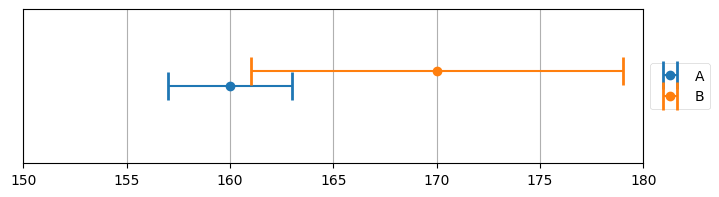

In [ ]:
book_plots.plot_errorbars([(160, 3, 'A'), (170, 9, 'B')], xlims=(150, 180))

传感器 A 返回了 160 的测量值，传感器 B 返回了 170 的测量值。图中的[*误差线*](https://zh.wikipedia.org/wiki/%E8%AA%A4%E5%B7%AE%E7%B7%9A)说明了该测量可能存在的误差范围。因此，传感器 A 实际测量的值可能在 157 到 163 之间，传感器 B 测量的值可能在 161 到 179 之间。

虽然我之前没有明确定义，但是这是一个[*均匀分布*](https://zh.wikipedia.org/wiki/%E5%9D%87%E5%8B%BB%E5%88%86%E5%B8%83)。均匀分布将等概率分配给范围内的任何事件。根据这个模型，传感器 A 读取 157、160 或 163 的概率相等。范围之外的任何值概率为 0。

我们可以用高斯分布模拟这种情况。我将使用 $\mathcal{N}(160, 3^2)$ 表示传感器 A，$\mathcal{N}(170, 9^2)$ 表示传感器 B。下面绘制这些高斯分布和均匀分布误差线的图示用于进行比较。

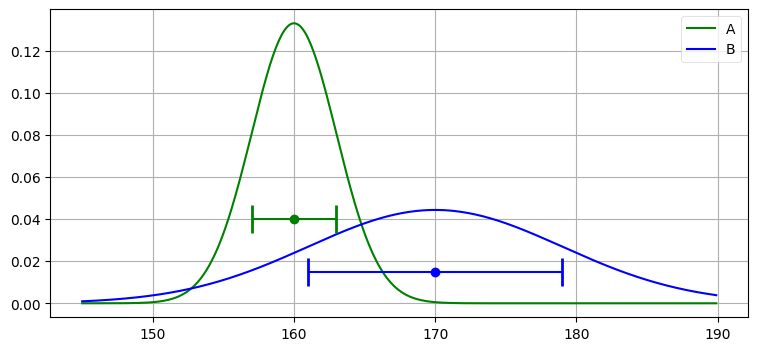

In [ ]:
xs = np.arange(145, 190, 0.1)
ys = [stats.gaussian(x, 160, 3**2) for x in xs]
plt.plot(xs, ys, label='A', color='g')

ys = [stats.gaussian(x, 170, 9**2) for x in xs]
plt.plot(xs, ys, label='B', color='b')
plt.legend();
plt.errorbar(160, [0.04], xerr=[3], fmt='o', color='g', capthick=2, capsize=10)    
plt.errorbar(170, [0.015], xerr=[9], fmt='o', color='b', capthick=2, capsize=10);

使用均匀分布或高斯分布是一种建模选择，但两者都不能完全描述现实。在大多数情况下，高斯分布更加真实。大多数传感器返回的读数接近被测量的值，不太可能返回远离该值的读数。高斯分布模拟了这种趋势。相比之下，均匀分布假定在范围内任何测量值都是等可能的。

现在让我们来看看在离散贝叶斯滤波器中使用的*离散分布*。该模型将可能的值域划分为离散范围，并为每个区间分配概率。只要这些概率相加等于一，这种分配就可以是完全任意的。

让我们使用均匀分布、高斯分布和离散分布对一个传感器的数据进行绘图。

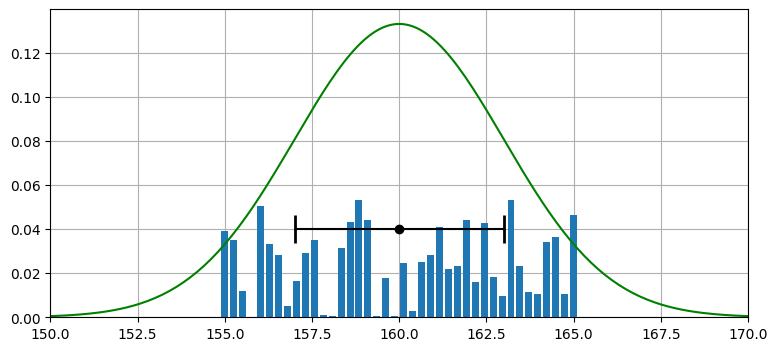

In [ ]:
from random import random
xs = np.arange(145, 190, 0.1)
ys = [stats.gaussian(x, 160, 3**2) for x in xs]
belief = np.array([random() for _ in range(40)])
belief = belief / sum(belief)

x = np.linspace(155, 165, len(belief))
plt.gca().bar(x, belief, width=0.2)
plt.plot(xs, ys, label='A', color='g')
plt.errorbar(160, [0.04], xerr=[3], fmt='o', color='k', capthick=2, capsize=10)    
plt.xlim(150, 170);

我使用随机数生成了离散分布，以说明它可以模拟任何任意的概率分布，这赋予了它巨大的能力。只要离散桶足够多，我们就可以对任何传感器的误差特性进行建模，无论其有多么复杂。但这种能力带来了数学上的难度。将高斯分布相乘或相加只需要两行数学，结果就是另一个高斯分布。这种规律性使我们能够对滤波器的性能和行为进行强大的分析。而将离散分布相乘或相加则需要循环遍历数据，我们没有简单的方式来描述结果。因此，基于离散分布进行滤波器性能特性的分析非常困难，甚至是不可能的。

在这里没有“正确”的选择。在本书的后面，我们将介绍使用离散分布的*粒子滤波器*。它是一种极其强大的技术，因为它可以处理任意复杂的情况。但这种技术的代价是性能较慢，而且难以进行分析。

目前，我们将忽略这些问题，并在接下来的几章中继续使用高斯分布。随着我们的进展，您将学习在我们的数学模型中使用高斯分布的优点和限制。

## 滤波器设计导论

到目前为止，我们已经为位置传感器开发了滤波器。我们现在已经熟悉了这个问题，但是可能觉得还无法对不同的问题实现卡尔曼滤波器。老实说，这个演示文稿中还简略了很多信息。以下章节将填补这些空白。让我们先通过设计和实现温度计的卡尔曼滤波器来感受一下。温度传感器输出与被测温度相对应的电压。我们已经阅读了制造商提供的传感器规格，它告诉我们传感器具有白噪声，标准偏差为 0.13 伏。

我们可以利用以下函数模拟温度传感器的测量：

In [ ]:
def volt(voltage, std):
    return voltage + (randn() * std)

现在我们需要编写卡尔曼滤波器的循环。和前面的问题一样，我们每个周期需要执行一次预测和更新。测量的步骤很清晰——调用`volt()`获取测量值，将结果传递到`update()`方法，但是预测步骤呢？我们没有一个用来检测电压的“移动”的传感器，并且在很短的时间内，我们希望电压保持恒定。我们该怎么办？

像往常一样，我们更相信数学计算。我们没有已知的运动模式，所以我们将温度的变化量设为零。然而，这意味着我们预测的温度永远不会改变。如果这是真的，那么随着时间的推移，我们应该对我们的结果变得非常自信。一旦滤波器具有足够的测量值，它将变得非常有信心能够预测随后的温度，这将导致它将忽略由于实际温度变化而引起的测量结果的改变。你需要避免这些被称为“沾沾自喜”的滤波器。所以我们需要在预测步骤中增加一点误差，告诉滤波器不要考虑电压随时间的变化。在下面的代码中，我设置了`process_var=.05**2`。这是每个时间周期内期望的电压变化的方差。我选择这个值只是为了能够通过更新和预测步骤显示方差是如何变化的。对于真正的传感器，您将根据预期的实际可能的变化量来设置该值。例如，如果这是一个用于测量室内环境空气温度的温度计，那么这个数字将非常小；如果这是一个用于化学反应室的热电偶，那么这个数字将非常高。我们将在后面的章节中详细介绍如何在实际中选择值。

让我们看看代码实现。

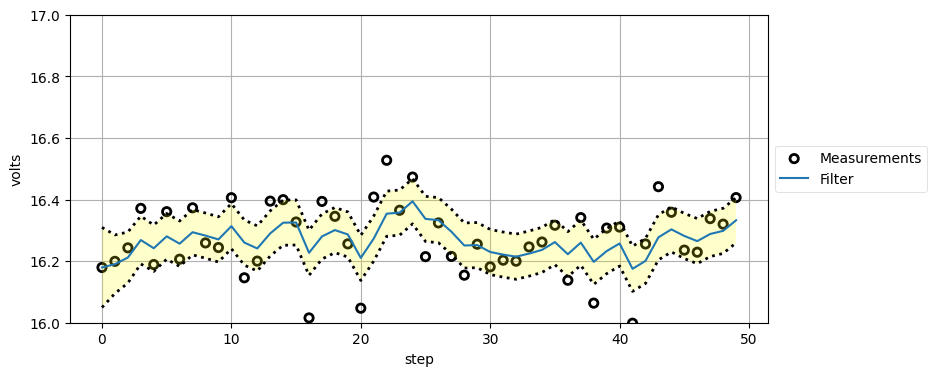

Variance converges to 0.005


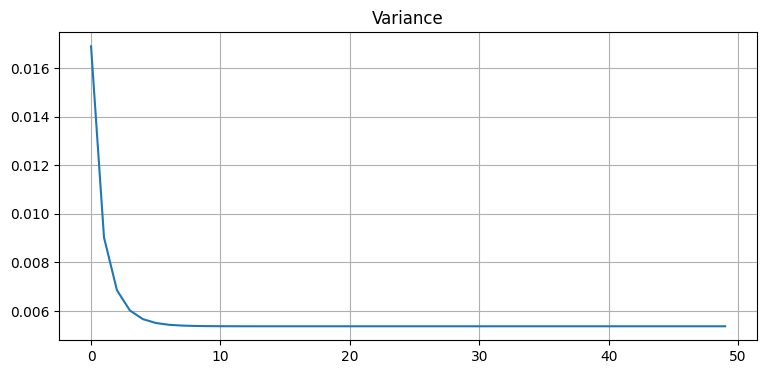

In [ ]:
temp_change = 0
voltage_std = .13
process_var = .05**2
actual_voltage = 16.3

x = gaussian(25., 1000.) # initial state
process_model = gaussian(0., process_var)

N = 50
zs = [volt(actual_voltage, voltage_std) for i in range(N)]
ps = []
estimates = []

for z in zs:
    prior = predict(x, process_model)
    x = update(prior, gaussian(z, voltage_std**2))

    # save for latter plotting
    estimates.append(x.mean)
    ps.append(x.var)

# plot the filter output and the variance
book_plots.plot_measurements(zs)
book_plots.plot_filter(estimates, var=np.array(ps))
book_plots.show_legend()
plt.ylim(16, 17)
book_plots.set_labels(x='step', y='volts')
plt.show()
    
plt.plot(ps)
plt.title('Variance')
print('Variance converges to {:.3f}'.format(ps[-1]))

第一张图显示了单个传感器测量值与滤波器输出值的关系。尽管传感器中有很多噪声，我们很快发现了传感器的近似电压。在我编写后的第一次运行的结果中，滤波器的最后一个电压输出是$16.213$，这与使用`volt()`函数得到的$16.4$非常接近。在其他运行中，我得到了与此相比或大和或小的结果。

规格表就像它的名字一样，是系统规格的表格。由于正常制造过程中的差异，任何单个传感器都会表现出不同的性能。规格表中的值通常是最大值——说明性能至少能保证会有那么好性能的。如果你买了一件昂贵的设备，它通常会附带一张纸，上面显示该产品的测试结果；这通常是非常值得信赖的。另一方面，如果这是一个廉价的传感器，它很可能在销售前几乎没有进行任何测试。制造商通常只测试一小部分，以验证样本是否在所需的性能范围内。如果您有一个关键的应用程序，您将需要仔细阅读规格表，以确定它们的范围究竟意味着什么。他们是否保证这个值是最大值，或者说存在$3\sigma$错误率？是否都经过了测试？是正态分布还是其它分布？最后，制造过程并不完美。您的零件可能存在缺陷，会与规格表上所列的性能不符。

例如，空气流量传感器的规格表。有一个字段为*复现率*，值为$\pm 0.50\%$。这是高斯分布吗？是否存在偏差呢？例如，在低温下，复现率可能接近$0.0\%$，而在高温下，复现率可能会接近$+0.50\%$。电气部件的规格表通常包含“典型性能特征”一节。它们用于描述表中不容易传递的信息。例如，一张显示 LM555 定时器输出电压和电流的图表。有三条曲线显示了不同温度下的性能。理想情况下，响应是线性的，但这三条线都是曲线。这就说明了在这个芯片输出的电压的误差可能不是高斯的，较高的温度会导致较低的电压输出，如果输入电流非常高，输出电压会是非线性的。

正如你可能认为的那样，对传感器的性能建模是设计卡尔曼滤波器最困难的地方之一。

### 动画

对于那些在浏览器中阅读此内容的读者，这里有一个显示滤波器工作的动画。如果您不使用浏览器，可以点击 https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python/blob/master/animations/05_volt_animate.gif 浏览。

<img src='animations/05_volt_animate.gif'>

动画中上面的图中的绿线为预测的下一个电压，红色“+”为实际测量值，浅红色线表示二者的差值，蓝色的线为滤波器的输出值。您可以看到，当滤波器启动时，所做的校正相当大，但在经过几次更新之后，即使测量值距离预测值很远，滤波器也只调整少量的输出。

下面的图显示了滤波器的置信度的高斯分布变化。当滤波器开始时，由于我们对电压的初始值猜测的不确定性，高斯曲线的中心超过 25，曲线非常宽而且矮。但是随着滤波器的更新，高斯分布很快移动到 16.0，并且变得很高，反映出滤波器对其电压估计的信心越来越大。你也会注意到高斯分布的高度有点上下波动。如果你仔细观察，你会发现高斯分布在预测步骤中会变得更短、更分散，但随着滤波器合并另一个测量值而变得更高、更窄。

把这个动画想象成 g-h 滤波器。在每个步骤中，g-h 滤波器会进行预测，测量，计算残差（预测和测量之间的差异），然后根据比例因子$g$选择残差线上的一个点。除了比例因子$g$是随时间变化的，卡尔曼滤波器做的是完全相同的事情。当滤波器对其状态更加自信时，比例因子会偏向滤波器的预测，而不是测量。

## 示例：大量的噪音

我猜测狗在 0 位置时，我没有在检测狗的滤波器信号中注入太多的噪声。滤波器在真实环境中是如何工作的呢？我将首先在 RFID 传感器的测量结果中注入更多的噪声，同时将过程方差保持在 2 m$^2$。我将会注入大量的噪声，这显然会淹没实际测量结果。如果传感器的标准偏差为 300 米，你的直觉认为滤波器的性能怎么样？换句话说，1.0 m 的实际位置可能返回的结果是 287.9 m 或 -589.6 m，或大致在该范围内的任何其他数字。在向下阅读之前先思考一下这个问题。

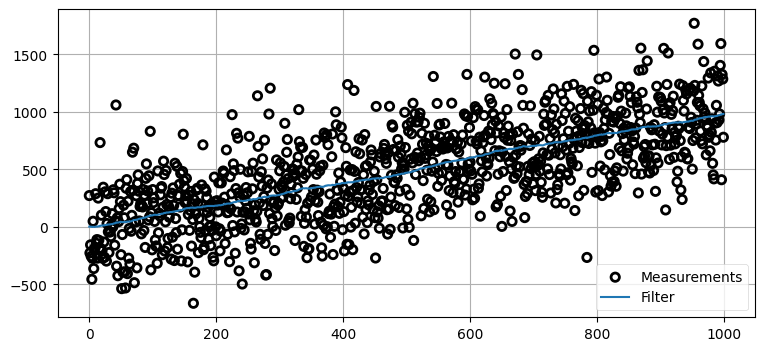

In [ ]:
sensor_var = 300.**2
process_var = 2.
process_model = gaussian(1., process_var)
pos = gaussian(0., 500.)
N = 1000
dog = DogSimulation(pos.mean, 1., sensor_var, process_var)
zs = [dog.move_and_sense() for _ in range(N)]
ps = []

for i in range(N):
    prior = predict(pos, process_model)    
    pos = update(prior, gaussian(zs[i], sensor_var))
    ps.append(pos.mean)

book_plots.plot_measurements(zs, lw=1)
book_plots.plot_filter(ps)
plt.legend(loc=4);

这个例子中噪音非常大，但滤波器的输出仍然几乎是一条直线！这是一个惊人的结果！您认为它能有这种表现的原因是什么？

我们得到一条近似直线，因为我们的过程误差很小。一个小的过程误差告诉滤波器预测它的预测结果是一条直线是非常可信的，因此滤波器的输出几乎是直线。

## 示例：不正确的过程方差

上一个滤波器看起来很棒！为什么我们不将过程方差设置得再低一些，让它可以保证结果是直的和平滑的？

过程方差告诉滤波器系统随时间变化的程度。如果您人为设置此数字，对滤波器撒谎，则滤波器将无法对正在发生的更改做出反应。我们让狗在每个时间步长内增加一小部分速度，看看具有 0.001 m$^2$的过程方差的滤波器如何执行。

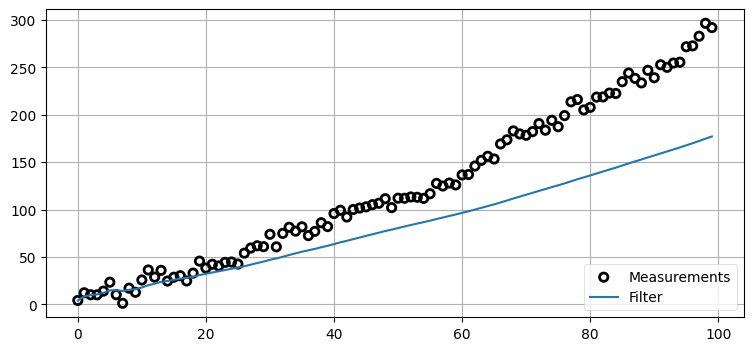

In [ ]:
sensor_var = 20.
process_var = .001
process_model = gaussian(1., process_var)
pos = gaussian(0., 500.)
N = 100
dog = DogSimulation(pos.mean, 1, sensor_var, process_var*10000)
zs, ps = [], []
for _ in range(N):
    dog.velocity += 0.04
    zs.append(dog.move_and_sense())

for z in zs:
    prior = predict(pos, process_model)    
    pos = update(prior, gaussian(z, sensor_var))
    ps.append(pos.mean)

book_plots.plot_measurements(zs, lw=1)
book_plots.plot_filter(ps)
plt.legend(loc=4);

很容易从上图看出滤波器没有正确响应测量结果。测量结果清楚地表明狗正在改变速度，但滤波器已经被告知它的预测几乎是正确的，所以它几乎完全忽略了它们。我鼓励你调整狗的运动量与过程方差。我们还将在后面的章节中更多地研究这个主题。关键是要认识到数学计算要求方差能够正确描述您的系统。滤波器不会“注意到”它与测量结果发生偏差并自行校正。它根据先验概率和测量值的方差计算卡尔曼增益，并根据哪个更准确形成估计。

## 示例：错误的初始估计

现在让我们看一下当我们对位置做出错误的初步估计时的结果。为了避免影响结果，我将传感器方差减小到 25，但将初始位置设置为 1000 米。滤波器可以从 1000 米的误差中恢复吗？

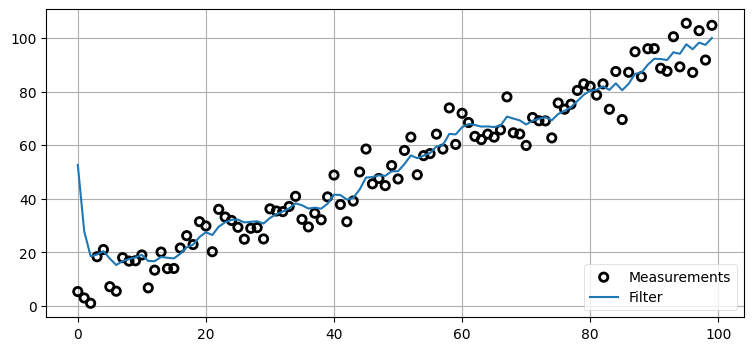

In [ ]:
sensor_var = 5.**2
process_var = 2.
pos = gaussian(1000., 500.)
process_model = gaussian(1., process_var)
N = 100
dog = DogSimulation(0, 1, sensor_var, process_var)
zs = [dog.move_and_sense() for _ in range(N)]
ps = []

for z in zs:
    prior = predict(pos, process_model)    
    pos = update(prior, gaussian(z, sensor_var))
    ps.append(pos.mean)

book_plots.plot_measurements(zs, lw=1)
book_plots.plot_filter(ps)
plt.legend(loc=4);

答案是肯定的！因为我们相对确信传感器的置信度 ($\sigma^2=5^2$)，仅在第一步之后我们就将位置估计从 1000 米改到大约 50 米。经过另外 5-10 次测量后，我们已收敛到正确的值。这就是我们如何解决最初猜测的鸡和蛋问题。在实践中，我们可能会将传感器的第一个测量值指定为初始值，但是如果我们在初始条件下猜测的很离谱，您可以看到它并不重要——只要选择的滤波器方差与实际过程方差和测量方差相匹配，卡尔曼滤波器仍会收敛。 

## 示例：大量的噪声和糟糕的初始估计

那如果这两个都很糟糕呢？既有大量的噪音，又有糟糕的初始估计。

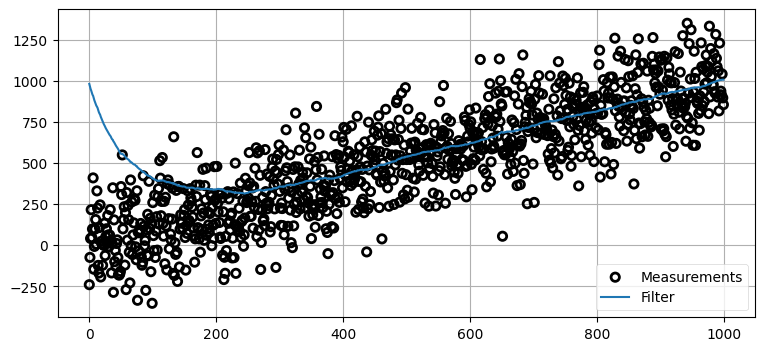

In [ ]:
sensor_var = 30000.
process_var = 2.
pos = gaussian(1000., 500.)
process_model = gaussian(1., process_var)

N = 1000
dog = DogSimulation(0, 1, sensor_var, process_var)
zs = [dog.move_and_sense() for _ in range(N)]
ps = []

for z in zs:
    prior = predict(pos, process_model) 
    pos = update(prior, gaussian(z, sensor_var))
    ps.append(pos.mean)

book_plots.plot_measurements(zs, lw=1)
book_plots.plot_filter(ps)
plt.legend(loc=4);

这次滤波器有些挣扎。但是请注意，前面的示例仅计算了 100 次更新，而这次示例计算了 1000。在我看来，滤波器 400 次左右时的迭代已经变得合理准确了，超过 600 次后的结果已经很良好了。卡尔曼滤波器很有用，但我们不能指望奇迹。如果我们有极其嘈杂的数据和非常糟糕的初始条件，那么这已经得到足够好的。

最后，让我们实现使用第一个测量作为初始位置。

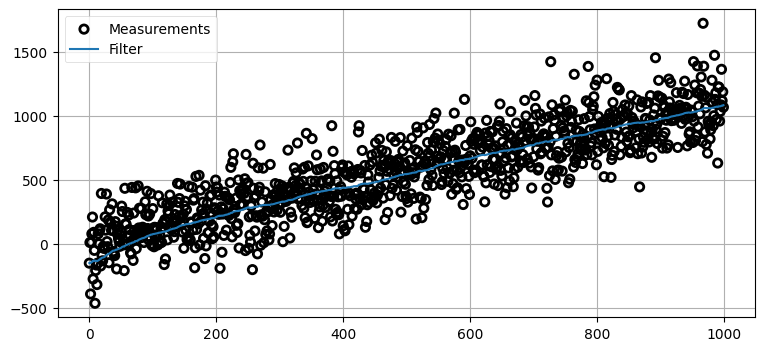

In [ ]:
sensor_var = 30000.
process_var = 2.
process_model = gaussian(1., process_var)
N = 1000
dog = DogSimulation(0, 1, sensor_var, process_var)
zs = [dog.move_and_sense() for _ in range(N)]

pos = gaussian(zs[0], 500.)
ps = []
for z in zs:
    prior = predict(pos, process_model) 
    pos = update(prior, gaussian(z, sensor_var))
    ps.append(pos.mean)

book_plots.plot_measurements(zs, lw=1)
book_plots.plot_filter(ps)
plt.legend(loc='best');

这种简单的改变显著地改善了结果。在有的运行中，需要 200 次迭代才能找到一个好的解决方案，但是有些时候它会很快收敛。这一切都取决于第一次测量中的噪声量。大量噪音会导致初始估计远离狗的位置。

200 次迭代可能看起来很多，但我们注入的噪音量确实很大。在现实世界中，我们使用的温度计，激光测距仪，GPS 卫星，计算机视觉等传感器，都不会有这么大的误差。便宜温度计的合理方差可能是 0.2 $^\circ\text{C}^{2}$，我们的代码使用$30,000$ $^\circ\text{C}^{2}$。

使用 Jupyter Notebook 的动画功能实现卡尔曼滤波器，您可以使用滑块实时地修改各个变量。请参阅**高斯分布**一章中的**交互式高斯**部分，了解如何执行此操作。您可以使用`interact()`函数来调用计算和绘图函数。传递给`interact()`的每个参数都会自动获取为对应的滑块的值。我为此编写了样板文件; 你需要填写所需的代码。

In [ ]:
from ipywidgets import interact
from kf_book.book_plots import FloatSlider

def plot_kalman_filter(start_pos, 
                       sensor_noise, 
                       velocity, 
                       process_noise):
    plt.figure();
    # your code goes here

interact(plot_kalman_filter,
         start_pos=(-10, 10), 
         sensor_noise=FloatSlider(value=5, min=0, max=100), 
         velocity=FloatSlider(value=1, min=-2., max=2.), 
         process_noise=FloatSlider(value=5, min=0, max=100.));

interactive(children=(IntSlider(value=0, description='start_pos', max=10, min=-10), FloatSlider(value=5.0, con…

### 答案

下面是一个一个可行的解决方案。我们的滑块对应起始位置，传感器中的噪音量，我们在每个时间步中移动的量以及有多少移动误差。过程噪声可能是最不明确的——它模拟了狗在每个时间步长偏离了多少，所以我们在每一步都将它加到狗的位置上。我设置随机数生成器种子，以便每次重新绘制使用的是相同的随机数，方便我们在移动滑块时比较图形。

In [ ]:
from numpy.random import seed 
from ipywidgets import interact

def plot_kalman_filter(start_pos, 
                       sensor_noise, 
                       velocity,
                       process_noise):
    N = 20
    zs, ps = [], []   
    seed(303)
    dog = DogSimulation(start_pos, velocity, sensor_noise, process_noise)
    zs = [dog.move_and_sense() for _ in range(N)]
    pos = gaussian(0., 1000.) # mean and variance
    process_model = gaussian(velocity, process_noise)
    
    for z in zs:    
        pos = predict(pos, process_model)
        pos = update(pos, gaussian(z, sensor_noise))
        ps.append(pos.mean)

    plt.figure()
    plt.plot(zs, c='k', marker='o', linestyle='', label='measurement')
    plt.plot(ps, c='#004080', alpha=0.7, label='filter')
    plt.legend(loc=4);

interact(plot_kalman_filter,
         start_pos=(-10, 10), 
         sensor_noise=FloatSlider(value=5, min=0., max=100), 
         velocity=FloatSlider(value=1, min=-2., max=2.), 
         process_noise=FloatSlider(value=.1, min=0, max=40));

interactive(children=(IntSlider(value=0, description='start_pos', max=10, min=-10), FloatSlider(value=5.0, con…

## 练习 —— 非线性系统

我们的卡尔曼滤波器方程是线性的：

$$\begin{aligned}
\mathcal{N}(\bar\mu,\, \bar\sigma^2) &= \mathcal{N}(\mu,\, \sigma^2) + \mathcal{N}(\mu_\mathtt{move},\, \sigma^2_\mathtt{move})\\
\mathcal{N}(\mu,\, \sigma^2) &= \mathcal{N}(\bar\mu,\, \bar\sigma^2)  \times \mathcal{N}(\mu_\mathtt{z},\, \sigma^2_\mathtt{z})
\end{aligned}$$

您认为卡尔曼滤波器在非线性系统中能否运行良好？

使用下面的等式生成测量值，实现卡尔曼滤波器。

```python
for i in range(100):
    z = math.sin(i/3.) * 2
```
    
调整方差和初始位置以查看效果。例如，初始猜测非常糟糕的结果是怎么样的？

In [ ]:
#enter your code here.

### 答案

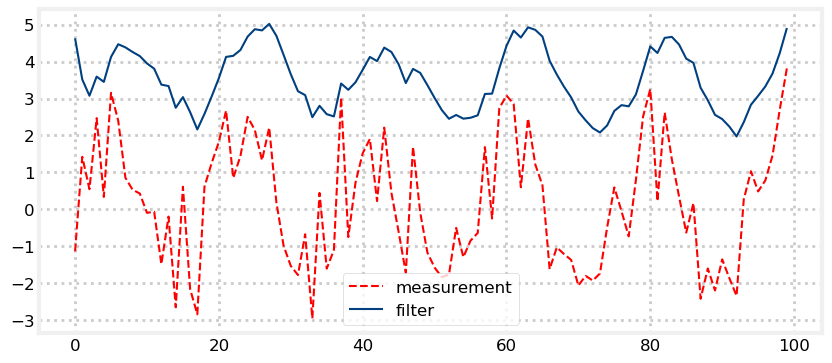

In [ ]:
import math

sensor_var = 30.
process_var = 2.
pos = gaussian(100., 500.)
process_model = gaussian(1., process_var)

zs, ps = [], []

for i in range(100):
    pos = predict(pos, process_model)

    z = math.sin(i/3.)*2 + randn()*1.2
    zs.append(z)
    
    pos = update(pos, gaussian(z, sensor_var))
    ps.append(pos.mean)

plt.plot(zs, c='r', linestyle='dashed', label='measurement')
plt.plot(ps, c='#004080', label='filter')
plt.legend(loc='best');

### 讨论

结果很糟糕！除了最粗略的方式外，输出完全不像一个正弦曲线。使用线性系统，我们可以为信号添加极大量的噪声，仍能提取非常准确的结果。但对于非线性系统显示即使是轻微的噪声也会产生非常糟糕的结果。

如果我们回想起**g-h 滤波器**一章，我们就可以理解这里发生了什么。g-h 滤波器的结构要求滤波器输出在预测和测量之间选择一个值。像这样总是在加速变化的信号，而我们的过程模型假定速度是恒定，因此滤波器在数学上导致输出总是滞后于输入信号。

相关研究者从开始实施卡尔曼滤波器后不久，他们就认识到卡尔曼滤波器在非线性系统中表现不佳，并开始设计处理它的方法。后面的章节专门讨论这个问题。

## 固定滤波器增益

嵌入式计算机处理器通常非常有限。许多设备没有浮点计算能力。之前这些简单的方程式会给芯片带来沉重的计算负担。随着技术的进步，这种情况就不那么真实，但是当你购买数百万美元时，不要低估在处理器上花费 1 美元的价值。

在上面的示例中，滤波器的方差收敛到固定值。如果测量和过程的方差是常数，则总会发生这种情况。您可以通过运行模拟来确定方差收敛的方式来确定这一事实。然后，您可以将此值硬编码到滤波器中。只要您使用良好的初始猜测将滤波器进行初始化（我建议使用第一个测量值作为初始值），滤波器将表现得非常好。例如，跟踪狗的滤波器可以简化为：

```python
def update(x, z):
    K = .13232  # experimentally derived Kalman gain
    y = z - x   # residual
    x = x + K*y # posterior
    return x
    
def predict(x):
    return x + vel*dt
```

我使用了更新函数中的卡尔曼增益形式来强调我们根本不需要考虑方差。如果方差收敛到单个值，那么卡尔曼增益也是如此。

## FilterPy 的实现

FilterPy 实现了`predict()`和`update()`函数。它们不仅适用于本章开发的单变量案例，而且适用于我们在后续章节中学到的更为一般的多变量案例。它们的接口会略有不同。他们不把高斯分布作为元组，而是作为两个单独命名的变量。

`predict()`有几个参数，但我们只需要使用这四个：

```python
predict(x, P, u, Q)
```

`x`是系统的状态。 `P`是系统的方差。 `u`是在过程中产生的运动，而`Q`是过程中的噪音。因为大多数参数都是可选的，当你调用`predict()`时，你需要使用声明的参数。 `predict()`的第三个参数**就不是**`u`了。

这些可能是可怕的变量名称。他们确实是！正如我已经提到的，它们来自于控制理论的悠久历史，而您阅读的每篇论文或书籍都将使用这些名称。所以，我们必须习惯它。不记住它们意味着你永远无法阅读文献。

让我们试试状态$\mathcal N(10, 3)$和运动$\mathcal N(1, 4)$。我们预计最终排名为 11（10 + 1），方差为 7（3 + 4）。

In [ ]:
import filterpy.kalman as kf
kf.predict(x=10., P=3., u=1., Q=4.)

(11.0, 7.0)

`update`也需要几个参数，但是现在你只需要这四个：
 
```python
update(x, P, z, R)
```

和之前一样，`x`和`P`是系统的状态和方差。 `z`是测量值，`R`是测量方差。让我们执行前面预测语句来获取我们的先验概率，然后执行更新：

In [ ]:
x, P = kf.predict(x=10., P=3., u=1., Q=2.**2)
print('%.3f' % x)

x, P = kf.update(x=x, P=P, z=12., R=3.5**2)
print('%.3f' % x, '%.3f' % P)

11.000
11.364 4.455


我给它一个嘈杂的测量值，测量值有很大的方差，所以估计值仍然接近先验值 11。

最后一点。我没有使用变量名称`prior`作为预测步骤的输出。我不会在本书的其余部分使用该变量名。卡尔曼滤波器方程只使用 $\mathbf x$。先验和后验都是系统的估计状态，前者是在结合测量之前状态的估计，后者是在结合测量之后的估计。

## 总结

我们在本章中描述的卡尔曼滤波器是我们接下来将学习的通用滤波器的特殊情况。大多数文献都不讨论这种一维形式。但是，我认为这是一个重要的垫脚石。我们用 g-h 滤波器开始了本书，然后实现了离散贝叶斯滤波器，现在实现了一维卡尔曼滤波器。我试图向您展示这些过滤器中的每一个都使用了相同的算法和推导过程。我们将很快学会的卡尔曼滤波器的数学计算是相当复杂的，并且很难理解滤波器简单的基本特性。这种复杂性带来了显着的好处：广义过滤器将明显优于本章中的过滤器。

本章的内容需要时间来吸收。要想真正理解它，您可能需要多次阅读本章。我鼓励您更改代码中的各种变量并观察结果。说服自己，高斯分布可以很好地表示一个狗在走廊中的位置，飞机在天空中的位置或化学反应室的温度的单模态置信度。然后说服自己，高斯分布的乘法确实可以根据先验概率的置信度和新的测量值计算出一种新的置信度。最后，说服自己，如果你正在测量运动，那么将高斯分布相加能够更新置信度。

最重要的是，花费足够的时间阅读**算法的完整描述**部分，以确保您了解该算法以及它与 g-h 滤波器和离散贝叶斯滤波器的关系。这里只有一个“技巧”——在预测和测量之间选择一个值。每种算法都使用不同的数学运算来执行该技巧，但都使用相同的逻辑。